In [105]:
import pandas as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Flatten,Dropout
from keras.regularizers import Regularizer
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_circles
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [106]:
import os

os.environ['KAGGLE_USERNAME'] = 'aishik996'
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_61236d6a08ac73ba31896583260ad688'

In [107]:
!kaggle datasets download -d saurabh00007/diabetescsv

Dataset URL: https://www.kaggle.com/datasets/saurabh00007/diabetescsv
License(s): CC0-1.0
diabetescsv.zip: Skipping, found more recently modified local copy (use --force to force download)


In [108]:
import zipfile

with zipfile.ZipFile('diabetescsv.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [67]:
df=pd.read_csv('/content/data/diabetes.csv')

In [17]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [109]:
X=df.iloc[:,0:-1].values
y=df.iloc[:,-1].values

In [110]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [111]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [23]:
!pip install -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.3 MB/s eta 0:00:00


In [71]:
import keras_tuner as kt

In [25]:
def build_model(hp):
  model=Sequential()

  model.add(Dense(128,activation='relu',input_dim=8))
  model.add(Dense(1,activation='sigmoid'))

  optimizer=hp.Choice('optimizer',values=['adam','rmsprop','adadelta'])

  model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])

  return model

In [26]:
tuner=kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    directory='project',
    project_name='diabetes'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
tuner.search(X_train,y_train,epochs=10,validation_data=(X_test,y_test))

Trial 3 Complete [00h 00m 04s]
val_accuracy: 0.8181818127632141

Best val_accuracy So Far: 0.8181818127632141
Total elapsed time: 00h 00m 18s


In [28]:
model=tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [29]:
model.fit(X_train,y_train,epochs=100,initial_epoch=11,validation_data=(X_test,y_test))

Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.7704 - loss: 0.4664 - val_accuracy: 0.8247 - val_loss: 0.4281
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7785 - loss: 0.4603 - val_accuracy: 0.8182 - val_loss: 0.4293
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7801 - loss: 0.4572 - val_accuracy: 0.8247 - val_loss: 0.4260
Epoch 15/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7785 - loss: 0.4563 - val_accuracy: 0.8117 - val_loss: 0.4254
Epoch 16/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7801 - loss: 0.4540 - val_accuracy: 0.8117 - val_loss: 0.4265
Epoch 17/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7785 - loss: 0.4521 - val_accuracy: 0.8247 - val_loss: 0.4280
Epoch 18/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7818 - loss: 0.4498 - val_accuracy: 0.8247 - val_loss: 0.4290
Epoch 19/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7866 - loss: 0.4482 - val_accuracy

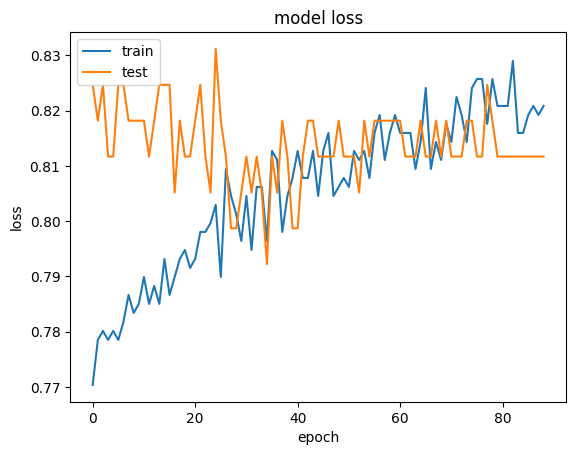

In [33]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [112]:
def build_model(hp):
  model=Sequential()

  counter=0
  for i in range(hp.Int('num_layers',min_value=1,max_value=10)):
    if counter ==0:
      model.add(Dense(
          hp.Int(
              'units'+str(i),min_value=8,max_value=512,step=8
              ),
                 activation=hp.Choice(
                     'activation'+str(i),values=['tanh','sigmoid','relu']
                     ),
                 input_dim=8)
          )
    if hp.Boolean("dropout"):
        model.add(Dropout(hp.Float('dropout'+str(i),min_value=0.1,max_value=0.9,step=0.1)))
    else:
      model.add(Dense(
          hp.Int(
              'units'+str(i),min_value=8,max_value=512,step=8
              ),
                 activation=hp.Choice(
                     'activation'+str(i),values=['tanh','sigmoid','relu']
                     ))
          )

    model.add(Dense(1,activation='sigmoid'))
    counter+=1

  model.compile(optimizer=hp.Choice('optimizers',values=['adam','rmsprop','adadelta','nadam','sgd']),
                                    loss='binary_crossentropy',
                                    metrics=['accuracy'])
  return model

In [113]:
tuner=kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    project_name='diabetes_tuner2',
    directory='project'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [114]:
tuner.search(X_train,y_train,epochs=10,validation_data=(X_test,y_test))

Trial 20 Complete [00h 00m 05s]
val_accuracy: 0.6948052048683167

Best val_accuracy So Far: 0.8181818127632141
Total elapsed time: 00h 03m 56s


In [115]:
model=tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 11 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [116]:
model.fit(X_train,y_train,epochs=100,initial_epoch=11,validation_data=(X_test,y_test))

Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.7736 - loss: 0.4724 - val_accuracy: 0.8052 - val_loss: 0.4399
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7769 - loss: 0.4661 - val_accuracy: 0.8052 - val_loss: 0.4379
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7769 - loss: 0.4662 - val_accuracy: 0.8117 - val_loss: 0.4341
Epoch 15/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7834 - loss: 0.4588 - val_accuracy: 0.8247 - val_loss: 0.4320
Epoch 16/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7785 - loss: 0.4609 - val_accuracy: 0.8182 - val_loss: 0.4348
Epoch 17/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7769 - loss: 0.4596 - val_accuracy: 0.8052 - val_loss: 0.4362
Epoch 18/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7687 - loss: 0.4559 - val_accuracy: 0.8052 - val_loss: 0.4361
Epoch 19/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7736 - loss: 0.4527 - val_accuracy: 

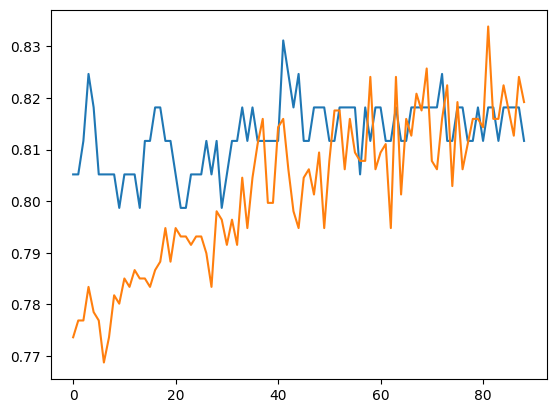

In [117]:
plt.plot(model.history.history['val_accuracy'])
plt.plot(model.history.history['accuracy'])
plt.show()

In [118]:
hyper=tuner.get_best_hyperparameters()[0].values

In [119]:
print(hyper)

{'num_layers': 1, 'units0': 152, 'activation0': 'relu', 'dropout': True, 'optimizers': 'nadam', 'dropout0': 0.1}


In [120]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 152)            │         1,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 152)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,566 (17.84 KB)

 Trainable params: 1,521 (5.94 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,045 (11.90 KB)